**TITLE :**
 - Project Team ID : PTID-CDS-FEB-26-4009
 - Project ID : PRCL-0019-Sales Effectiveness
 - Domain: Sales & Marketing Analytics

**INTRODUCTION:**

This project aims to improve sales effectiveness at FicZon Inc by using machine learning techniques to predict the quality of sales leads. FicZon receives a large number of leads through its website and digital channels, but not all leads have the same potential to convert into sales. Currently, lead quality assessment is done manually by the sales team, which is time-consuming and dependent on human judgment. In this project, lead data is analyzed and a machine learning model is built to classify leads as High Potential or Low Potential, enabling the sales team to focus on the most valuable customers.

**DATA DESCRIPTION :**

**Overview :**

The dataset contains information related to sales leads generated by FicZon Inc through digital platforms, primarily via the company’s website. It includes details about lead creation, product interest, lead source, customer contact availability, sales agent assignment, geographic location, and delivery mode. The objective of this dataset is to analyze sales effectiveness and to predict the quality of leads by classifying them as High Potential or Low Potential, enabling the sales team to focus on valuable prospects and improve overall sales performance.

**Number of Rows and Columns :**

- Number of rows: 7,422
- Number of columns: 9
    - 8 input features
    - 1 output feature

**Feature Description :**

1. Created (Created) :

    - Represents the date and time when the sales lead was created.
    - This feature helps analyze lead generation trends over time.

2. Product ID (Product_ID) :
  
    - Indicates the product or solution the lead is interested in.
    - Helps identify products with higher lead conversion potential.

3. Lead Source (Source) :

    - Represents the channel through which the lead was generated (e.g., website, digital marketing).
    - Different sources may produce leads with varying quality.

4. Mobile Availability (Mobile) :

    - Indicates whether the lead has provided a mobile phone number.
    - Leads with mobile contact details generally have higher engagement chances.

5. Email Availability (EMAIL) :

    - Indicates whether the lead has provided an email address.
    - Availability of email enables effective follow-up communication.

6. Sales Agent (Sales_Agent) :

    - Represents the sales representative assigned to the lead.
    - Helps evaluate individual sales agent effectiveness.

7. Location (Location) :

    - Indicates the geographic location of the lead.
    - Location may influence product demand and conversion rates.

8. Delivery Mode (Delivery_Mode) :

    - Represents the type of product delivery preferred (On-Premises or SaaS).
    - Delivery mode impacts customer preference and purchasing behavior.

9. Lead Status (Target Variable – Status) :

    - Indicates the quality of the sales lead.

        - High Potential → Likely to convert into a sale
        - Low Potential → Less likely to convert

**Variable Types :**

- Input variables include categorical and date-based features.
- Binary indicators are used for contact availability (Mobile, Email).
- The output variable is binary categorical.        

In [1]:
import os
from sqlalchemy import create_engine
import mysql.connector
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
from urllib.parse import quote_plus

user = "dm_team2"
raw_password = "DM!$Team&27@9!20!"  
password = quote_plus(raw_password)

host = "18.136.157.135"
port = "3306"    
db = "project_sales"

engine = create_engine(
    f"mysql+pymysql://{user}:{password}@{host}:{port}/{db}"
)


In [3]:
engine.connect()


In [4]:
query = "SELECT * FROM data"
df = pd.read_sql(query, engine)


In [5]:
df

,Created,Product_ID,Source,Mobile,EMAIL,Sales_Agent,Location,Delivery_Mode,Status
0,14-11-2018 10:05,,Website,984XXXXXXX,aXXXXXXX@gmail.com,Sales-Agent-11,,Mode-5,Open
1,14-11-2018 09:22,,Website,XXXXXXX,#VALUE!,Sales-Agent-10,,Mode-5,Open
2,14-11-2018 09:21,,Website,XXXXXXX,dXXXXXXX@yahoo.com,Sales-Agent-10,,Mode-5,Open
3,14-11-2018 08:46,,Website,XXXXXXX,wXXXXXXX@gmail.com,Sales-Agent-10,,Mode-5,Open
4,14-11-2018 07:34,,Website,XXXXXXX,cXXXXXXX@gmail.com,Sales-Agent-10,,Mode-5,Open
...,...,...,...,...,...,...,...,...,...
7417,28-04-2018 09:45,9,Call,,aXXXXXXX@gmail.com,Sales-Agent-6,Mumbai,Mode-4,LOST
7418,28-04-2018 09:43,15,Call,,#VALUE!,Sales-Agent-12,Other Locations,Mode-5,LOST
7419,28-04-2018 09:20,5,Live Chat-Direct,,sXXXXXXX@gmail.com,Sales-Agent-11,Bangalore,Mode-1,Not Responding
7420,28-04-2018 08:04,21,CRM form,,YXXXXXXX@gmail.com,Sales-Agent-4,Other Locations,Mode-1,Just Enquiry


In [6]:
df.shape

(7422, 9)

In [7]:
df.columns

Index(['Created', 'Product_ID', 'Source', 'Mobile', 'EMAIL', 'Sales_Agent',
       'Location', 'Delivery_Mode', 'Status'],
      dtype='object')

In [8]:
df.head()

,Created,Product_ID,Source,Mobile,EMAIL,Sales_Agent,Location,Delivery_Mode,Status
0,14-11-2018 10:05,,Website,984XXXXXXX,aXXXXXXX@gmail.com,Sales-Agent-11,,Mode-5,Open
1,14-11-2018 09:22,,Website,XXXXXXX,#VALUE!,Sales-Agent-10,,Mode-5,Open
2,14-11-2018 09:21,,Website,XXXXXXX,dXXXXXXX@yahoo.com,Sales-Agent-10,,Mode-5,Open
3,14-11-2018 08:46,,Website,XXXXXXX,wXXXXXXX@gmail.com,Sales-Agent-10,,Mode-5,Open
4,14-11-2018 07:34,,Website,XXXXXXX,cXXXXXXX@gmail.com,Sales-Agent-10,,Mode-5,Open


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7422 entries, 0 to 7421
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Created        7422 non-null   object
 1   Product_ID     7422 non-null   object
 2   Source         7422 non-null   object
 3   Mobile         7422 non-null   object
 4   EMAIL          7422 non-null   object
 5   Sales_Agent    7422 non-null   object
 6   Location       7422 non-null   object
 7   Delivery_Mode  7422 non-null   object
 8   Status         7422 non-null   object
dtypes: object(9)
memory usage: 522.0+ KB


In [10]:
df.describe()

,Created,Product_ID,Source,Mobile,EMAIL,Sales_Agent,Location,Delivery_Mode,Status
count,7422,7422,7422,7422,7422,7422,7422,7422,7422
unique,6752,30,26,487,883,13,18,5,11
top,26-09-2018 11:30,18,Call,,#VALUE!,Sales-Agent-4,Other Locations,Mode-5,Junk Lead
freq,4,1711,2547,1810,1701,1500,2500,2975,1536


In [11]:
df2=df.copy()

In [12]:
df2.columns = df2.columns.str.lower()
df2.columns

Index(['created', 'product_id', 'source', 'mobile', 'email', 'sales_agent',
       'location', 'delivery_mode', 'status'],
      dtype='object')

**EXPLORATORY DATA ANALYSIS:**

**Product_ID:**

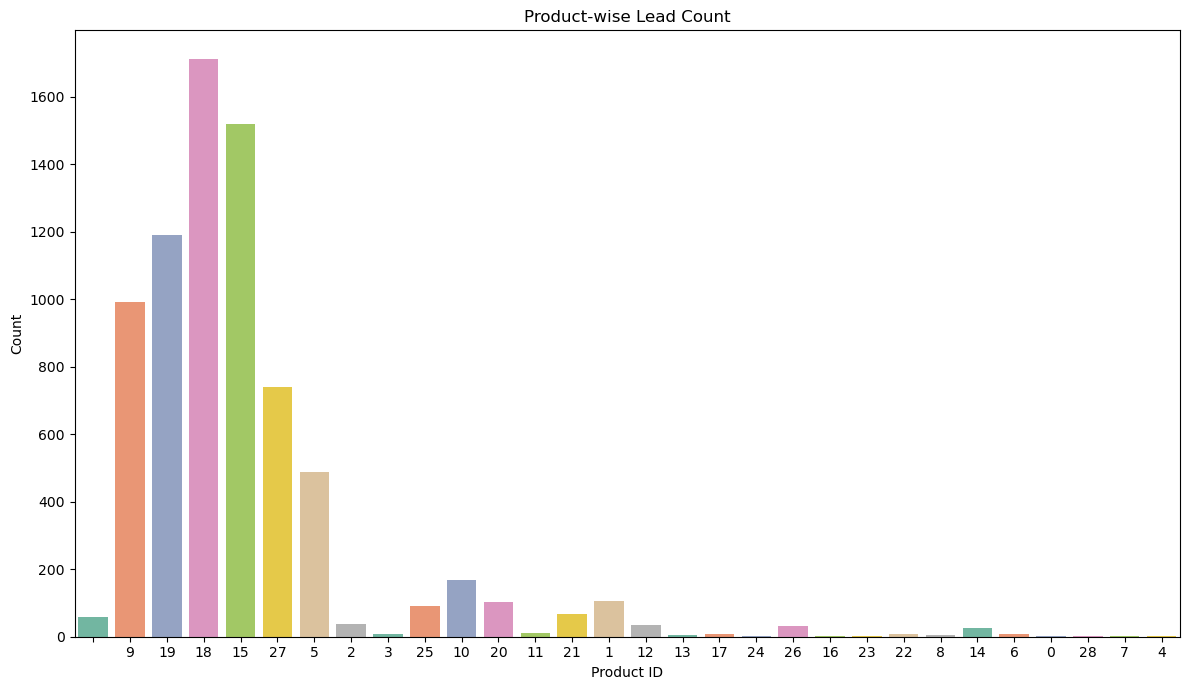

In [13]:
plt.figure(figsize=(12,7))
sns.countplot(x='product_id',data=df2,palette='Set2')
plt.xlabel('Product ID')
plt.ylabel('Count')
plt.title('Product-wise Lead Count')
plt.tight_layout()
plt.show()

**Analysis:**

- A few products dominate lead generation, while most products contribute very few leads.
- Product IDs 18, 15, 19, and 9 generate the highest number of leads.
- The distribution is highly imbalanced, indicating unequal product demand.
- High-performing products should be prioritized by the sales team for better conversion.
- Low-lead products may need improved marketing or strategic review.

**Source:**

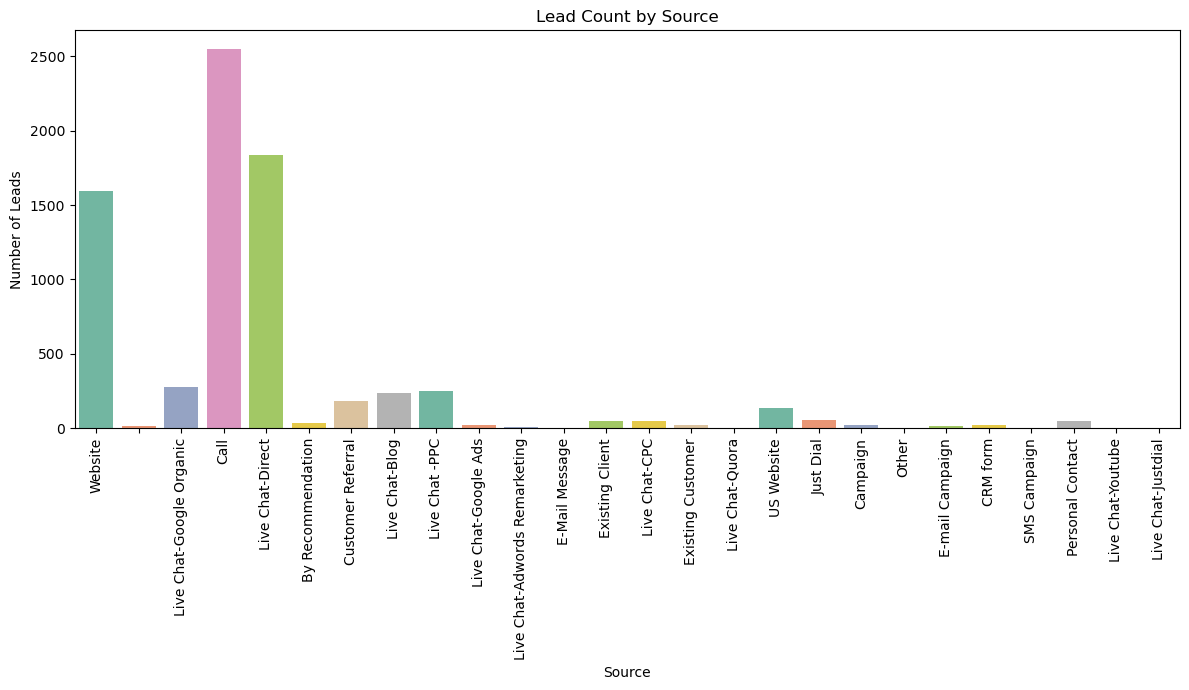

In [14]:
plt.figure(figsize=(12,7))
sns.countplot(x='source',data=df2,palette='Set2')
plt.xticks(rotation=90)
plt.xlabel('Source')
plt.ylabel('Number of Leads')
plt.title('Lead Count by Source')
plt.tight_layout()
plt.show()


**Analysis:**

- Call, Live Chat–Direct, and Website are the top lead-generating sources, contributing the majority of leads.
- Digital and real-time interaction channels (Live Chat, Website) outperform traditional sources.
- Several sources generate very few leads, indicating low effectiveness or limited usage.
- Lead distribution across sources is highly imbalanced, with a few dominant channels.
- High-performing sources should be prioritized for sales and marketing investment.

**Sales Agent:**

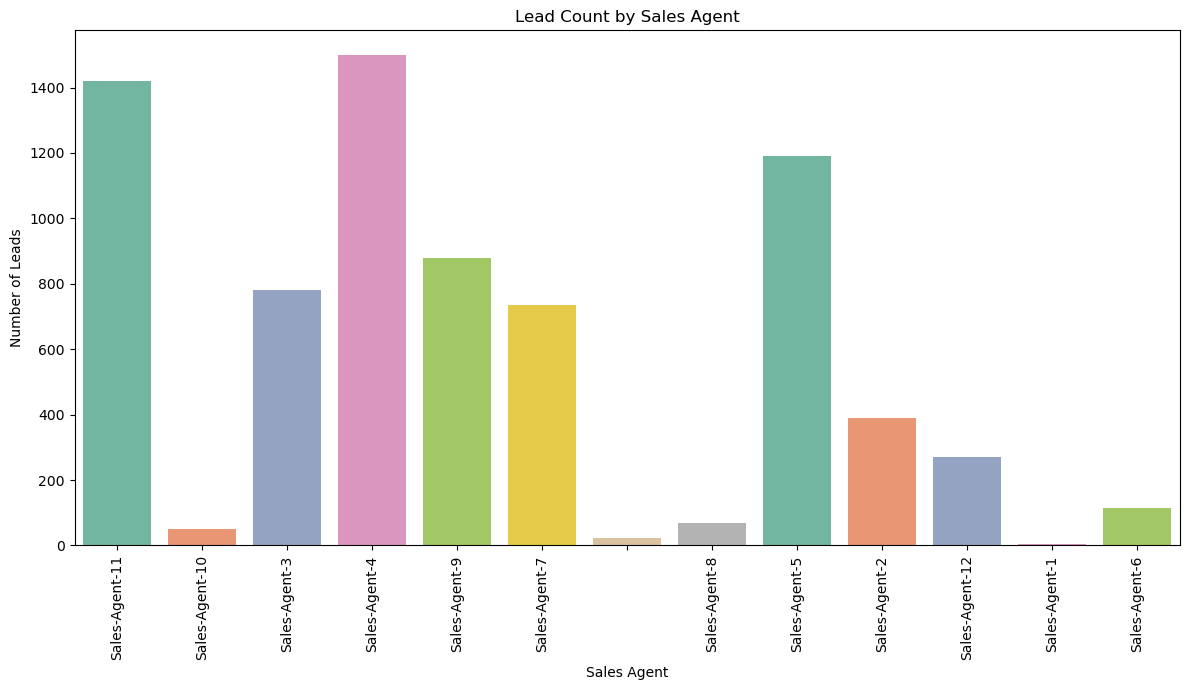

In [15]:
plt.figure(figsize=(12,7))
sns.countplot(x='sales_agent',data=df2,palette='Set2')
plt.xticks(rotation=90)
plt.xlabel('Sales Agent')
plt.ylabel('Number of Leads')
plt.title('Lead Count by Sales Agent')
plt.tight_layout()
plt.show()

**Analysis:**

- Sales-Agent-4, Sales-Agent-11, and Sales-Agent-5 handle the highest number of leads, indicating strong workload concentration.
- Lead distribution among sales agents is highly uneven, with a few agents managing most leads.
- Several agents have very low lead counts, suggesting under-utilization or limited assignment.
- Uneven lead allocation may impact sales effectiveness and conversion consistency.
- These insights can help in optimizing lead assignment and balancing sales workloads.

**Location:**

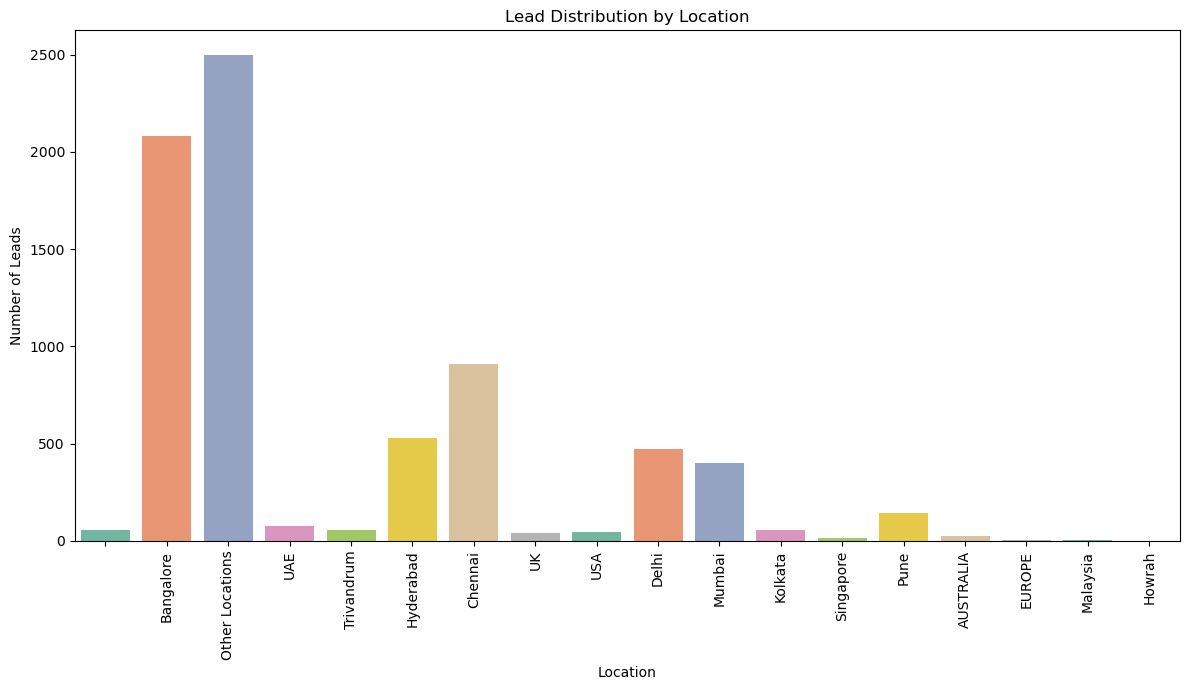

In [16]:
plt.figure(figsize=(12,7))
sns.countplot(x='location',data=df2,palette='Set2')
plt.xticks(rotation=90)
plt.xlabel('Location')
plt.ylabel('Number of Leads')
plt.title('Lead Distribution by Location')
plt.tight_layout()
plt.show()

**Analysis:**

- “Other Locations” and Bangalore contribute the highest number of leads, dominating the overall distribution.
- Major Indian cities like Chennai, Hyderabad, Delhi, and Mumbai show strong lead presence.
- International locations (USA, UK, UAE, Australia, Europe) contribute comparatively fewer leads.
- Lead distribution by location is highly imbalanced, with a few locations generating most leads.
- Location-wise insights can help focus regional sales and marketing strategies more effectively

**Delivery Mode:**

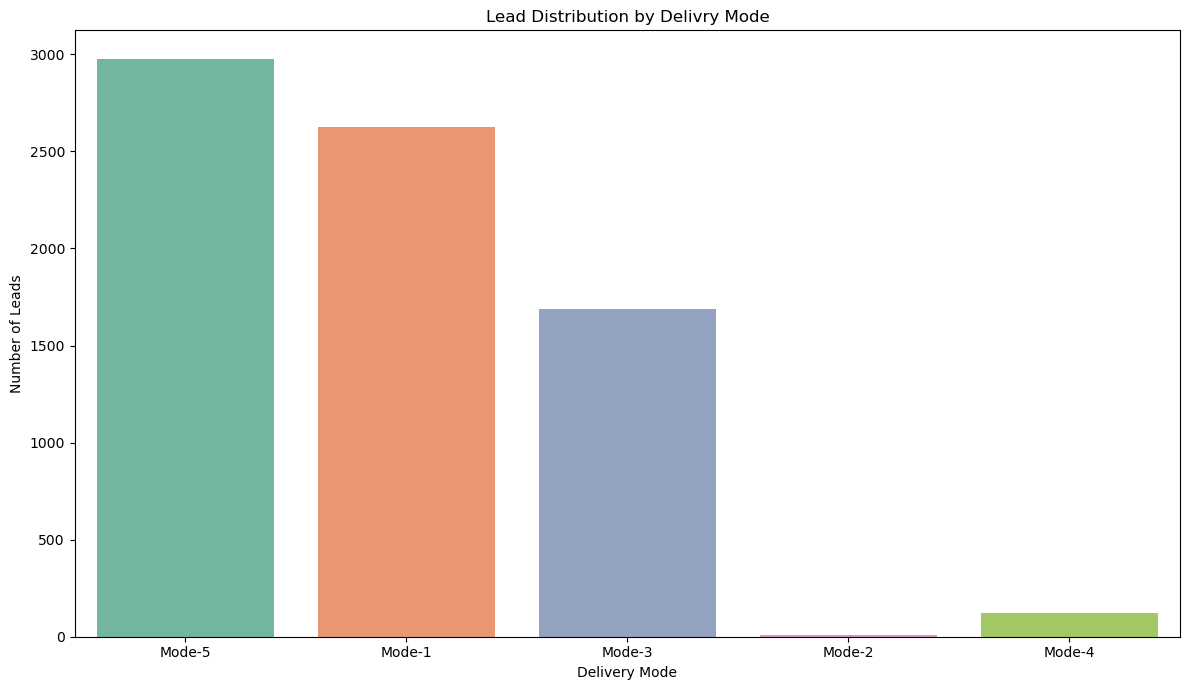

In [17]:
plt.figure(figsize=(12,7))
sns.countplot(x='delivery_mode',data=df2,palette='Set2')
plt.xlabel('Delivery Mode')
plt.ylabel('Number of Leads')
plt.title('Lead Distribution by Delivry Mode')
plt.tight_layout()
plt.show()

**Analysis:**

- Mode-5 and Mode-1 are the most preferred delivery modes, contributing the majority of leads.
- Mode-3 shows moderate usage compared to the top two modes.
- Mode-2 and Mode-4 generate very few leads, indicating low preference or limited availability.
- The distribution across delivery modes is highly imbalanced.
- Popular delivery modes should be prioritized in sales strategy, while low-usage modes may need review.

**Status:**

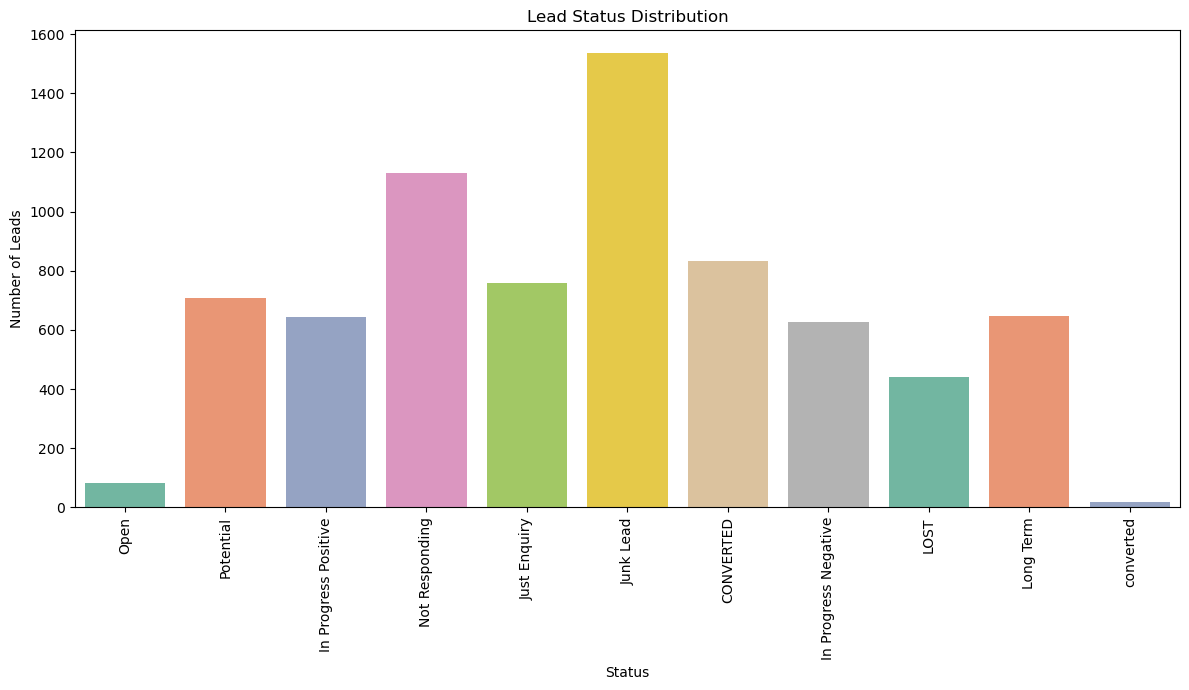

In [18]:
plt.figure(figsize=(12,7))
sns.countplot(x='status', data=df2,palette='Set2')
plt.xticks(rotation=90)
plt.xlabel('Status')
plt.ylabel('Number of Leads')
plt.title('Lead Status Distribution')
plt.tight_layout()
plt.show()


**Analysis:**

- Junk Lead is the most frequent status, indicating a large number of low-quality leads.
- A significant portion of leads fall under Not Responding and Just Enquiry, showing limited customer engagement.
- Converted leads are comparatively fewer, highlighting scope for improving conversion strategies.
- Lost and In-Progress Negative statuses indicate drop-offs during the sales process.
- The lead status distribution is highly imbalanced, which is important to consider during model training.

**DATA PREPROCESSING:**

In [19]:
df2.replace('', np.nan, inplace=True)

In [20]:
df2.head()

,created,product_id,source,mobile,email,sales_agent,location,delivery_mode,status
0,14-11-2018 10:05,NaN,Website,984XXXXXXX,aXXXXXXX@gmail.com,Sales-Agent-11,NaN,Mode-5,Open
1,14-11-2018 09:22,NaN,Website,XXXXXXX,#VALUE!,Sales-Agent-10,NaN,Mode-5,Open
2,14-11-2018 09:21,NaN,Website,XXXXXXX,dXXXXXXX@yahoo.com,Sales-Agent-10,NaN,Mode-5,Open
3,14-11-2018 08:46,NaN,Website,XXXXXXX,wXXXXXXX@gmail.com,Sales-Agent-10,NaN,Mode-5,Open
4,14-11-2018 07:34,NaN,Website,XXXXXXX,cXXXXXXX@gmail.com,Sales-Agent-10,NaN,Mode-5,Open


In [21]:
print('Null Values:')
display(df2.isnull().sum())

Null Values:


created             0
product_id         58
source             17
mobile           1810
email               0
sales_agent        23
location           58
delivery_mode       0
status              0
dtype: int64

In [22]:
cols = ['product_id', 'source','sales_agent','location']
for col in cols:
    print(f"{col} mode value:",df2[col].mode()[0])

product_id mode value: 18
source mode value: Call
sales_agent mode value: Sales-Agent-4
location mode value: Other Locations


In [23]:
for col in cols:
    df2[col] = df2[col].fillna(df2[col].mode()[0])

In [24]:
df2.isnull().sum()

created             0
product_id          0
source              0
mobile           1810
email               0
sales_agent         0
location            0
delivery_mode       0
status              0
dtype: int64

In [25]:
df2.head()

,created,product_id,source,mobile,email,sales_agent,location,delivery_mode,status
0,14-11-2018 10:05,18,Website,984XXXXXXX,aXXXXXXX@gmail.com,Sales-Agent-11,Other Locations,Mode-5,Open
1,14-11-2018 09:22,18,Website,XXXXXXX,#VALUE!,Sales-Agent-10,Other Locations,Mode-5,Open
2,14-11-2018 09:21,18,Website,XXXXXXX,dXXXXXXX@yahoo.com,Sales-Agent-10,Other Locations,Mode-5,Open
3,14-11-2018 08:46,18,Website,XXXXXXX,wXXXXXXX@gmail.com,Sales-Agent-10,Other Locations,Mode-5,Open
4,14-11-2018 07:34,18,Website,XXXXXXX,cXXXXXXX@gmail.com,Sales-Agent-10,Other Locations,Mode-5,Open


**Handling High Cardinality Features:**

**Product_ID:**

In [26]:
product_counts  = df2['product_id'].value_counts()
product_counts

product_id
18    1769
15    1518
19    1189
9      992
27     739
5      487
10     168
1      105
20     102
25      90
21      66
2       38
12      36
26      31
14      27
11      12
22       8
3        7
17       7
6        7
8        6
13       5
24       3
16       3
23       2
0        2
28       1
7        1
4        1
Name: count, dtype: int64

In [27]:
low_demand = product_counts[product_counts<=10].index
low_demand

Index(['22', '3', '17', '6', '8', '13', '24', '16', '23', '0', '28', '7', '4'], dtype='object', name='product_id')

In [28]:
df2.product_id.replace(low_demand,'low_demand',inplace=True)
df2.product_id.value_counts()

product_id
18            1769
15            1518
19            1189
9              992
27             739
5              487
10             168
1              105
20             102
25              90
21              66
low_demand      53
2               38
12              36
26              31
14              27
11              12
Name: count, dtype: int64

**Source:**

In [29]:
df2['source'].unique()

array(['Website', 'Call', 'Live Chat-Google Organic', 'Live Chat-Direct',
       'By Recommendation', 'Customer Referral', 'Live Chat-Blog',
       'Live Chat -PPC', 'Live Chat-Google Ads',
       'Live Chat-Adwords Remarketing', 'E-Mail Message',
       'Existing Client', 'Live Chat-CPC', 'Existing Customer',
       'Live Chat-Quora', 'US Website', 'Just Dial', 'Campaign', 'Other',
       'E-mail Campaign', 'CRM form', 'SMS Campaign', 'Personal Contact',
       'Live Chat-Youtube', 'Live Chat-Justdial'], dtype=object)

In [30]:
df2.source.replace(
    ['Live Chat-Google Organic', 'Live Chat-Direct', 'Live Chat-Blog',
     'Live Chat -PPC', 'Live Chat-Google Ads',
     'Live Chat-Adwords Remarketing', 'Live Chat-CPC',
     'Live Chat-Quora', 'Live Chat-Youtube', 'Live Chat-Justdial'],'live_chat',inplace = True)

In [31]:
df2.source.replace(
    ['Website', 'US Website', 'CRM form'],'website',inplace=True)

In [32]:
df2.source.replace(
    ['By Recommendation', 'Customer Referral', 'Personal Contact'],'referral',inplace=True)

In [33]:
df2.source.replace(
     ['Campaign','E-Mail Message', 'E-mail Campaign', 'SMS Campaign'],'campaign',inplace=True)

In [34]:
df2.source.replace(
    ['Existing Client', 'Existing Customer'],'existing_cust',inplace=True)

In [35]:
df2.source.replace(
    ['Call', 'Just Dial'],'direct',inplace=True)

In [36]:
df2['source'].value_counts()

source
live_chat        2677
direct           2620
website          1754
referral          262
existing_cust      73
campaign           34
Other               2
Name: count, dtype: int64

**Location:**

In [37]:
df2.location.replace(['Trivandrum','Kolkata','Howrah','Other Locations'],'other Location',inplace=True)
df2.location.replace(['UAE','Malaysia','Singapore'],'asia',inplace=True)
df2.location.replace(['USA','UK','AUSTRALIA','EUROPE'],'west country',inplace = True)

In [38]:
df2.location.value_counts()

location
other Location    2672
Bangalore         2084
Chennai            909
Hyderabad          528
Delhi              471
Mumbai             402
Pune               142
west country       114
asia               100
Name: count, dtype: int64

**Status:**

In [39]:
df2['status'].unique()

array(['Open', 'Potential', 'In Progress Positive', 'Not Responding',
       'Just Enquiry', 'Junk Lead', 'CONVERTED', 'In Progress Negative',
       'LOST', 'Long Term', 'converted'], dtype=object)

In [40]:
df2.status.replace(['Junk Lead','Not Responding','In Progress Negative','Just Enquiry','LOST'],'low potential',inplace=True)
df2.status.replace(['CONVERTED','Potential','Long Term','In Progress Positive','Open','converted'],'high potential',inplace=True)

In [41]:
df2['status'].unique()

array(['high potential', 'low potential'], dtype=object)

In [42]:
df2.status.value_counts()

status
low potential     4491
high potential    2931
Name: count, dtype: int64

**Feature Encoding:**

**Frequency encoding:**

Frequency encoding was used to convert high-cardinality categorical features into numerical form by replacing each category with its occurrence count. This helps reduce dimensionality and improves model efficiency without creating multiple dummy variables.

In [43]:
product_freq  = df2['product_id'].value_counts()
df2['product_id'] = df2['product_id'].map(product_freq)

In [44]:
source_freq = df2['source'].value_counts()
df2['source'] = df2['source'].map(source_freq)

In [45]:
agent_freq = df2['sales_agent'].value_counts()
df2['sales_agent'] = df2['sales_agent'].map(agent_freq)

In [46]:
location_freq = df2['location'].value_counts()
df2['location'] = df2['location'].map(location_freq)

In [47]:
delivery_ferq = df2['delivery_mode'].value_counts()
df2['delivery_mode'] = df2['delivery_mode'].map(delivery_ferq)

In [48]:
#label encoding
df2['status'] = df2['status'].map({
    'low potential' : 0,
    'high potential' : 1
})

In [49]:
df2.head()

,created,product_id,source,mobile,email,sales_agent,location,delivery_mode,status
0,14-11-2018 10:05,1769,1754,984XXXXXXX,aXXXXXXX@gmail.com,1420,2672,2975,1
1,14-11-2018 09:22,1769,1754,XXXXXXX,#VALUE!,49,2672,2975,1
2,14-11-2018 09:21,1769,1754,XXXXXXX,dXXXXXXX@yahoo.com,49,2672,2975,1
3,14-11-2018 08:46,1769,1754,XXXXXXX,wXXXXXXX@gmail.com,49,2672,2975,1
4,14-11-2018 07:34,1769,1754,XXXXXXX,cXXXXXXX@gmail.com,49,2672,2975,1


In [50]:
df2 = df2.drop(['created','mobile','email'],axis=1, errors = 'ignore')

In [51]:
df2.columns

Index(['product_id', 'source', 'sales_agent', 'location', 'delivery_mode',
       'status'],
      dtype='object')

In [52]:
df2.dtypes

product_id       int64
source           int64
sales_agent      int64
location         int64
delivery_mode    int64
status           int64
dtype: object

In [53]:
df2.head()

,product_id,source,sales_agent,location,delivery_mode,status
0,1769,1754,1420,2672,2975,1
1,1769,1754,49,2672,2975,1
2,1769,1754,49,2672,2975,1
3,1769,1754,49,2672,2975,1
4,1769,1754,49,2672,2975,1


**Correlation Analysis:**

In [54]:
corr = df2.corr()['status'].sort_values(ascending=False)
print(corr)

status           1.000000
product_id      -0.042855
sales_agent     -0.099012
location        -0.110917
delivery_mode   -0.119990
source          -0.150077
Name: status, dtype: float64


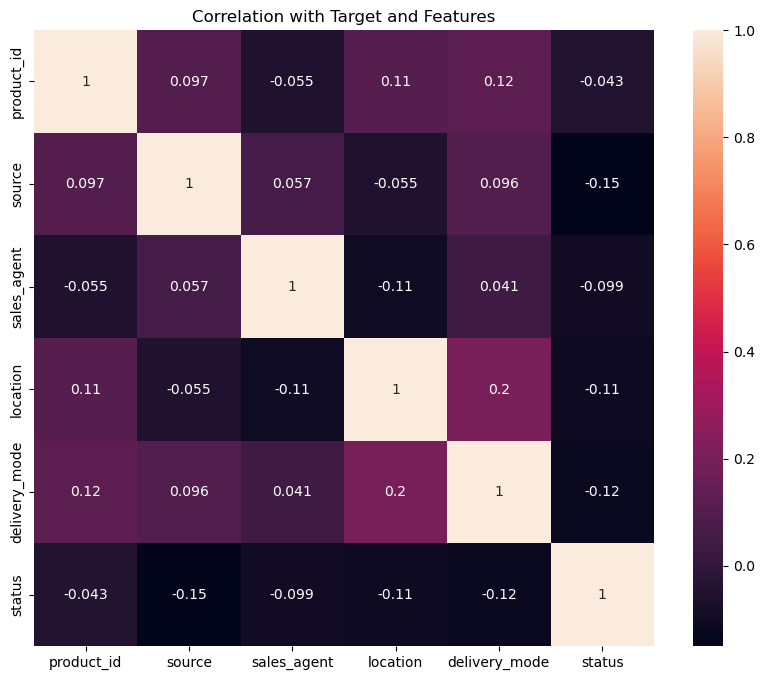

In [55]:
plt.figure(figsize=(10,8))
sns.heatmap(df2.corr(),annot=True)
plt.title("Correlation with Target and Features")
plt.show()

**Correlation Observation:**

The correlation analysis shows that none of the individual features have strong linear relationships with the target variable. The highest correlation observed is -0.15 (source), which indicates a weak negative influence. Overall, the low correlation values `msuggest that the relationship between features and the target may be non-linear.

**Saving Preprocessed Data:**

In [56]:
df2.to_csv("cleaned_data.csv", index=False)
data = pd.read_csv("cleaned_data.csv")

In [57]:
data

,product_id,source,sales_agent,location,delivery_mode,status
0,1769,1754,1420,2672,2975,1
1,1769,1754,49,2672,2975,1
2,1769,1754,49,2672,2975,1
3,1769,1754,49,2672,2975,1
4,1769,1754,49,2672,2975,1
...,...,...,...,...,...,...
7417,992,2620,114,402,121,0
7418,1518,2620,269,2672,2975,0
7419,487,2677,1420,2084,2627,0
7420,66,1754,1523,2672,2627,0


In [58]:
data.columns

Index(['product_id', 'source', 'sales_agent', 'location', 'delivery_mode',
       'status'],
      dtype='object')

**PREDICTIVE MODEL USING MACHINE LEARNING TECHNIQUES**

**Feature Selection:**

In [59]:
x = data.drop('status', axis=1)
y = data['status']

In [60]:
print("x(Input Features):\n", x.head())
print("\ny(Target Variable):\n",y.head())

x(Input Features):
    product_id  source  sales_agent  location  delivery_mode
0        1769    1754         1420      2672           2975
1        1769    1754           49      2672           2975
2        1769    1754           49      2672           2975
3        1769    1754           49      2672           2975
4        1769    1754           49      2672           2975

y(Target Variable):
 0    1
1    1
2    1
3    1
4    1
Name: status, dtype: int64


**Train-Test Split**

In [61]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

x_train,x_test,y_train,y_test = train_test_split(
    x,y,test_size=0.2,random_state=42)


scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [62]:
print("x_train shape:", x_train.shape)
print("x_test shape:", x_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

x_train shape: (5937, 5)
x_test shape: (1485, 5)
y_train shape: (5937,)
y_test shape: (1485,)


In [63]:
print("Train target distribution:")
print(y_train.value_counts())

print("\nTest target distribution:")
print(y_test.value_counts())

Train target distribution:
status
0    3601
1    2336
Name: count, dtype: int64

Test target distribution:
status
0    890
1    595
Name: count, dtype: int64


**Model Building:**

The following classification models are trained to predict the target variable:

 - Logistic Regression

 - Decision Tree

 - Random Forest

 - Gradient Boosting

 - KNeighbourClassifier

 - XGBoost

 - CatBoost
 
Since the target variable is imbalanced, SMOTE is applied on the training data before model training.

Model performance is evaluated and compared to select the best-performing model.

In [64]:
data.status.value_counts()

status
0    4491
1    2931
Name: count, dtype: int64

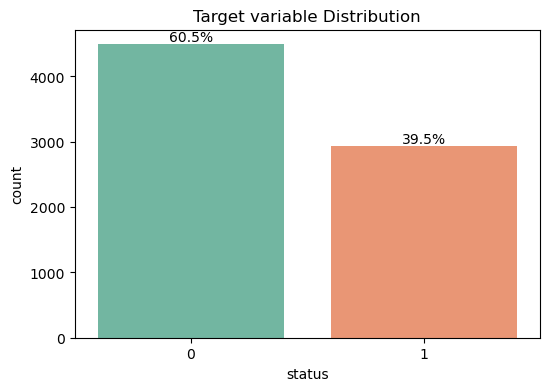

In [65]:
plt.figure(figsize=(6,4))
ax = sns.countplot(x='status',data=data,palette='Set2')
total = len(data)
for p in ax.patches:
    percentage = f'{100*p.get_height()/total:.1f}%'
    ax.annotate(percentage,
                (p.get_x()+p.get_width()/2.,p.get_height()),
                ha = 'center',va = 'bottom')
plt.title("Target variable Distribution")
plt.show()

In [66]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
x_train_sm,y_train_sm = smote.fit_resample(x_train,y_train)

In [67]:
from collections import Counter
print("Class distribution Before SMOTE:")
print(Counter(y_train))

print("\nClass distribution After SMOTE:")
print(Counter(y_train_sm))

Class distribution Before SMOTE:
Counter({0: 3601, 1: 2336})

Class distribution After SMOTE:
Counter({1: 3601, 0: 3601})


**1. LOGISTIC REGRESSION:**

In [68]:
from sklearn.linear_model import LogisticRegression
lgr = LogisticRegression(
    max_iter=1000,
    random_state=42)
lgr.fit(x_train_sm,y_train_sm)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [69]:
y_train_pred_lgr = lgr.predict(x_train_sm)
y_test_pred_lgr = lgr.predict(x_test)
y_test_pred_lgr

array([0, 0, 0, ..., 0, 1, 0], shape=(1485,))

In [70]:
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
accuracy_train_lgr = accuracy_score(y_train_sm,y_train_pred_lgr)
print("Accuracy_train_lgr:",accuracy_train_lgr)

accuracy_test_lgr = accuracy_score(y_test,y_test_pred_lgr)
print("Accuracy_test_lgr:",accuracy_test_lgr)

Accuracy_train_lgr: 0.5744237711746737
Accuracy_test_lgr: 0.5804713804713805


In [71]:
classification_report_train_lgr = classification_report(y_train_sm,y_train_pred_lgr)
print("Classificaton Report train_lgr:\n", classification_report_train_lgr)

classification_report_test_lgr = classification_report(y_test,y_test_pred_lgr)
print("\nClassification Report test_lgr:\n",classification_report_test_lgr)

Classificaton Report train_lgr:
               precision    recall  f1-score   support

           0       0.57      0.63      0.59      3601
           1       0.58      0.52      0.55      3601

    accuracy                           0.57      7202
   macro avg       0.58      0.57      0.57      7202
weighted avg       0.58      0.57      0.57      7202


Classification Report test_lgr:
               precision    recall  f1-score   support

           0       0.66      0.63      0.64       890
           1       0.48      0.50      0.49       595

    accuracy                           0.58      1485
   macro avg       0.57      0.57      0.57      1485
weighted avg       0.58      0.58      0.58      1485



In [72]:
cm_lgr = confusion_matrix(y_test,y_test_pred_lgr)
print("Cnofusion Matrix Test Set:\n", cm_lgr)

Cnofusion Matrix Test Set:
 [[562 328]
 [295 300]]


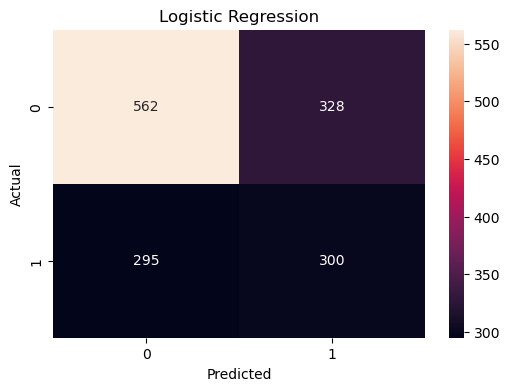

In [73]:
plt.figure(figsize=(6,4))
sns.heatmap(cm_lgr,annot=True,fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression")
plt.show()

In [74]:
from sklearn.metrics import recall_score,f1_score,roc_auc_score
y_test_pred_1  = y_test_pred_lgr
y_prob_lgr = lgr.predict_proba(x_test)[:,1]
recall_lgr = recall_score(y_test,y_test_pred_1)
f1_lgr = f1_score(y_test,y_test_pred_1)
roc_auc_lgr = roc_auc_score(y_test,y_prob_lgr)
print("Logistic Regression  Metrics:")
print("Recall:", recall_lgr)
print("F1:", f1_lgr)
print("ROC-AUC:",roc_auc_lgr)

Logistic Regression  Metrics:
Recall: 0.5042016806722689
F1: 0.49059689288634506
ROC-AUC: 0.6084836181663676


** 2.KNN CLASSIER: **`

In [75]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(x_train_sm,y_train_sm)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [76]:
y_train_pred_knn = knn.predict(x_train_sm)
y_test_pred_knn = knn.predict(x_test)
y_test_pred_knn

array([0, 0, 1, ..., 0, 0, 0], shape=(1485,))

In [77]:
accuracy_train_knn = accuracy_score(y_train_sm,y_train_pred_knn)
print("Accuracy_train_knn:",accuracy_train_knn)

accuracy_test_knn = accuracy_score(y_test,y_test_pred_knn)
print("Accuracy_test_knn:",accuracy_test_knn)

Accuracy_train_knn: 0.7746459316856429
Accuracy_test_knn: 0.6861952861952862


In [78]:
classification_report_train_knn = classification_report(y_train_sm,y_train_pred_knn)
print("Classification Report train_knn:\n",classification_report_train_knn)

classification_report_test_knn = classification_report(y_test,y_test_pred_knn)
print("\nClassification Report test_knn:\n",classification_report_test_knn)

Classification Report train_knn:
               precision    recall  f1-score   support

           0       0.76      0.81      0.78      3601
           1       0.79      0.74      0.77      3601

    accuracy                           0.77      7202
   macro avg       0.78      0.77      0.77      7202
weighted avg       0.78      0.77      0.77      7202


Classification Report test_knn:
               precision    recall  f1-score   support

           0       0.73      0.75      0.74       890
           1       0.61      0.59      0.60       595

    accuracy                           0.69      1485
   macro avg       0.67      0.67      0.67      1485
weighted avg       0.68      0.69      0.69      1485



In [79]:
cm_knn = confusion_matrix(y_test,y_test_pred_knn)
print("Confusion Matrix Test Set:\n",cm_knn)

Confusion Matrix Test Set:
 [[666 224]
 [242 353]]


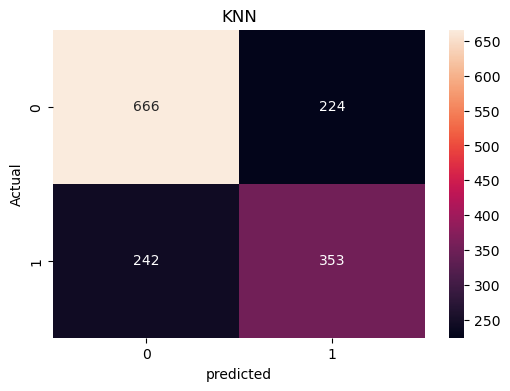

In [80]:
plt.figure(figsize=(6,4))
sns.heatmap(cm_knn,annot=True,fmt='d')
plt.xlabel("predicted")
plt.ylabel("Actual")
plt.title("KNN")
plt.show()

In [81]:
y_test_pred_2 = y_test_pred_knn
y_prob_knn = knn.predict_proba(x_test)[:,1]
recall_knn = recall_score(y_test,y_test_pred_2)
f1_knn = f1_score(y_test,y_test_pred_2)
roc_auc_knn = roc_auc_score(y_test,y_prob_knn)
print("KNN Metrics:")
print("Recall:",recall_knn)
print("F1:",f1_knn)
print("ROC-AUC:",roc_auc_knn)

KNN Metrics:
Recall: 0.5932773109243697
F1: 0.6023890784982935
ROC-AUC: 0.7450514587857615


**Hyperparameter Tuning - KNN:**

In [82]:
from sklearn.model_selection import GridSearchCV
param_grid_knn = {
    'n_neighbors' : [3,5,7,9,11],
    'weights' : ['uniform','manhattan']
}
knn_gs = KNeighborsClassifier()

In [83]:
grid_knn = GridSearchCV(
    knn_gs,
    param_grid_knn,
    cv=5,
    scoring='f1',
    n_jobs=-1
)
grid_knn.fit(x_train_sm,y_train_sm)

,estimator,KNeighborsClassifier()
,param_grid,"{'n_neighbors': [3, 5, ...], 'weights': ['uniform', 'manhattan']}"
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_neighbors,9


In [84]:
best_knn = grid_knn.best_estimator_
print("Best Parameters:",grid_knn.best_params_)

Best Parameters: {'n_neighbors': 9, 'weights': 'uniform'}


In [85]:
y_train_pred_knn_gs = best_knn.predict(x_train_sm)
y_test_pred_knn_gs = best_knn.predict(x_test)
y_test_pred_knn_gs

array([0, 0, 1, ..., 0, 0, 0], shape=(1485,))

In [86]:
accuracy_train_knn_gs = accuracy_score(y_train_sm,y_train_pred_knn)
print("Accuracy_train_knn_gs:",accuracy_train_knn_gs)

accuracy_test_knn_gs = accuracy_score(y_test,y_test_pred_knn_gs)
print("Accuracy__test_knn_gs:",accuracy_test_knn_gs)

Accuracy_train_knn_gs: 0.7746459316856429
Accuracy__test_knn_gs: 0.6915824915824916


In [87]:
classification_report_train_knn_gs = classification_report(y_train_sm,y_train_pred_knn_gs)
print("Classification Report train_knn:\n",classification_report_train_knn_gs)

classification_report_test_knn_gs = classification_report(y_test,y_test_pred_knn_gs)
print("Classification Report test_knn_gs:\n", classification_report_test_knn_gs)

Classification Report train_knn:
               precision    recall  f1-score   support

           0       0.76      0.76      0.76      3601
           1       0.76      0.76      0.76      3601

    accuracy                           0.76      7202
   macro avg       0.76      0.76      0.76      7202
weighted avg       0.76      0.76      0.76      7202

Classification Report test_knn_gs:
               precision    recall  f1-score   support

           0       0.75      0.73      0.74       890
           1       0.61      0.64      0.62       595

    accuracy                           0.69      1485
   macro avg       0.68      0.68      0.68      1485
weighted avg       0.69      0.69      0.69      1485



In [88]:
cm_knn_gs = confusion_matrix(y_test,y_test_pred_knn_gs)
print("Confusion Matrix Test Set:\n",cm_knn_gs)

Confusion Matrix Test Set:
 [[648 242]
 [216 379]]


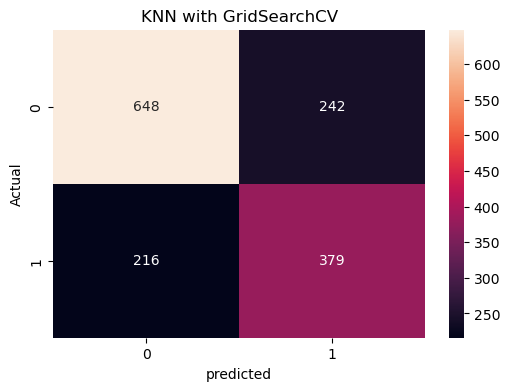

In [89]:
plt.figure(figsize=(6,4))
sns.heatmap(cm_knn_gs,annot=True,fmt='d')
plt.xlabel('predicted')
plt.ylabel('Actual')
plt.title('KNN with GridSearchCV')
plt.show()

In [90]:
y_test_pred_3 = y_test_pred_knn_gs
y_prob_knn_gs = best_knn.predict_proba(x_test)[:,1]
recall_knn_gs = recall_score(y_test,y_test_pred_3)
f1_knn_gs = f1_score(y_test,y_test_pred_3)
roc_auc_knn_gs = roc_auc_score(y_test,y_prob_knn_gs)
print("KNN (GS) Metrics:")
print("Recall:",recall_knn_gs)
print("F1:",f1_knn_gs)
print("ROC-AUC:",roc_auc_knn_gs)

KNN (GS) Metrics:
Recall: 0.6369747899159663
F1: 0.6233552631578947
ROC-AUC: 0.7650429610046265


**3. GRADIENTBOOSTING CLASSIFIER:**

In [91]:
from sklearn.ensemble import GradientBoostingClassifier
gb = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.1,
    random_state=42
)
gb.fit(x_train_sm,y_train_sm)

,loss,'log_loss'
,learning_rate,0.1
,n_estimators,200
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [92]:
y_train_pred_gb = gb.predict(x_train_sm)
y_test_pred_gb = gb.predict(x_test)
y_test_pred_gb

array([0, 0, 0, ..., 0, 0, 0], shape=(1485,))

In [93]:
accuracy_train_gb = accuracy_score(y_train_sm,y_train_pred_gb)
print("Accuracy_train_gb:",accuracy_train_gb)

accuracy_test_gb = accuracy_score(y_test,y_test_pred_gb)
print("Accuracy_test_gb:",accuracy_test_gb)

Accuracy_train_gb: 0.761455151346848
Accuracy_test_gb: 0.7232323232323232


In [94]:
classification_report_train_gb = classification_report(y_train_sm,y_train_pred_gb)
print("Classification Report train_gb:\n",classification_report_train_gb)

classification_report_test_gb = classification_report(y_test,y_test_pred_gb)
print("\nClassification Report test_gb:\n", classification_report_test_gb)

Classification Report train_gb:
               precision    recall  f1-score   support

           0       0.77      0.75      0.76      3601
           1       0.76      0.77      0.76      3601

    accuracy                           0.76      7202
   macro avg       0.76      0.76      0.76      7202
weighted avg       0.76      0.76      0.76      7202


Classification Report test_gb:
               precision    recall  f1-score   support

           0       0.78      0.76      0.77       890
           1       0.65      0.68      0.66       595

    accuracy                           0.72      1485
   macro avg       0.71      0.72      0.71      1485
weighted avg       0.73      0.72      0.72      1485



In [95]:
cm_gb = confusion_matrix(y_test,y_test_pred_gb)
print("Confusion Matrix Test Set:\n",cm_gb)

Confusion Matrix Test Set:
 [[672 218]
 [193 402]]


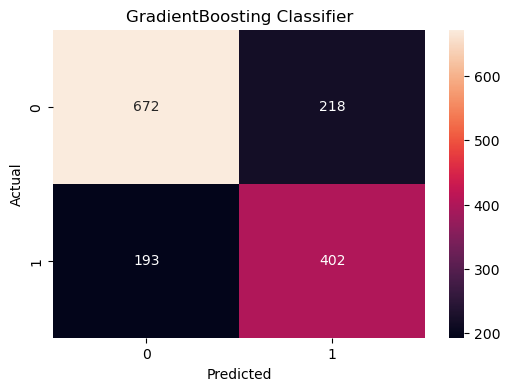

In [96]:
plt.figure(figsize=(6,4))
sns.heatmap(cm_gb,annot=True,fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('GradientBoosting Classifier')
plt.show()

In [97]:
y_test_pred_4 = y_test_pred_gb
y_prob_gb = gb.predict_proba(x_test)[:,1]
recall_gb = recall_score(y_test,y_test_pred_4)
f1_gb = f1_score(y_test,y_test_pred_4)
roc_auc_gb = roc_auc_score(y_test,y_prob_gb)
print("GradientBoosting Metrics:")
print("Recall:",recall_gb)
print("F1:",f1_gb)
print("ROC-AUC:",roc_auc_gb)

GradientBoosting Metrics:
Recall: 0.6756302521008404
F1: 0.6617283950617284
ROC-AUC: 0.8103248040789348


**4. DECISIONTREE CLASSIFIER:**

In [98]:
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier(random_state=42)
dt.fit(x_train_sm,y_train_sm)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [99]:
y_train_pred_dt = dt.predict(x_train_sm)
y_test_pred_dt = dt.predict(x_test)
y_test_pred_dt

array([0, 0, 1, ..., 0, 0, 0], shape=(1485,))

In [100]:
accuracy_train_dt = accuracy_score(y_train_sm,y_train_pred_dt)
print("Accuracy_train_dt:",accuracy_train_dt)

accuracy_test_dt = accuracy_score(y_test,y_test_pred_dt)
print("Accuracy_test_dt:",accuracy_test_dt)

Accuracy_train_dt: 0.8522632602054985
Accuracy_test_dt: 0.6794612794612794


In [101]:
classification_report_train_dt = classification_report(y_train_sm,y_train_pred_dt)
print("Classification Report_train_dt:\n", classification_report_train_dt)

classification_report_test_dt = classification_report(y_test,y_test_pred_dt)
print("\nClassification Report_test_dt:\n", classification_report_test_dt)

Classification Report_train_dt:
               precision    recall  f1-score   support

           0       0.84      0.88      0.86      3601
           1       0.87      0.83      0.85      3601

    accuracy                           0.85      7202
   macro avg       0.85      0.85      0.85      7202
weighted avg       0.85      0.85      0.85      7202


Classification Report_test_dt:
               precision    recall  f1-score   support

           0       0.72      0.77      0.74       890
           1       0.61      0.54      0.57       595

    accuracy                           0.68      1485
   macro avg       0.66      0.66      0.66      1485
weighted avg       0.67      0.68      0.68      1485



In [102]:
cm_dt = confusion_matrix(y_test,y_test_pred_dt)
print("Confusion Matrix Test Set:\n", cm_dt)


Confusion Matrix Test Set:
 [[687 203]
 [273 322]]


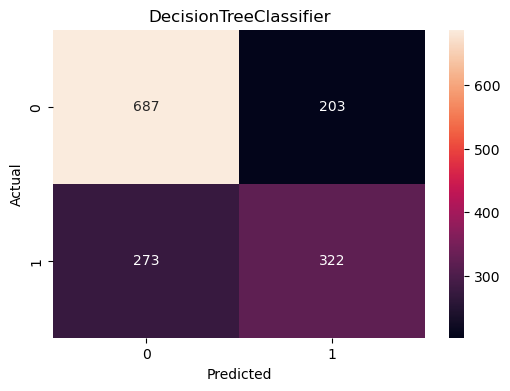

In [103]:
plt.figure(figsize=(6,4))
sns.heatmap(cm_dt,annot=True,fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('DecisionTreeClassifier')
plt.show()

In [104]:
y_test_pred_5 = y_test_pred_dt
y_prob_dt = dt.predict_proba(x_test)[:,1]
recall_dt = recall_score(y_test,y_test_pred_5)
f1_dt = f1_score(y_test,y_test_pred_5)
roc_auc_dt = roc_auc_score(y_test,y_prob_dt)
print("DecisionTreeClassifier Metrics:")
print("Recall:",recall_dt)
print("F1:",f1_dt)
print("ROC-AUC:",roc_auc_dt)


DecisionTreeClassifier Metrics:
Recall: 0.5411764705882353
F1: 0.575
ROC-AUC: 0.7046567840619393


**Hyperparameter Tuning - Decisiontree Classifier:**

In [105]:
param_grid_dt = {
    'max_depth' : [3,5,7,10,None],
    'min_samples_split' : [2,5,10,20],
    'min_samples_leaf' : [1,3,5,10],
    'criterion' : ['gini','entropy']
}
dt_gs = DecisionTreeClassifier(random_state=42)

In [106]:
grid_dt = GridSearchCV(
    estimator=dt_gs,
    param_grid=param_grid_dt,
    cv=5,
    scoring='f1',
    n_jobs=-1
)
grid_dt.fit(x_train_sm,y_train_sm)

,estimator,DecisionTreeC...ndom_state=42)
,param_grid,"{'criterion': ['gini', 'entropy'], 'max_depth': [3, 5, ...], 'min_samples_leaf': [1, 3, ...], 'min_samples_split': [2, 5, ...]}"
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'entropy'


In [107]:
print("Best Parameters:",grid_dt.best_params_)
best_dt = grid_dt.best_estimator_

Best Parameters: {'criterion': 'entropy', 'max_depth': 10, 'min_samples_leaf': 5, 'min_samples_split': 2}


In [108]:
y_train_pred_dt_gs = best_dt.predict(x_train_sm)
y_test_pred_dt_gs = best_dt.predict(x_test)
y_test_pred_dt_gs

array([1, 0, 1, ..., 0, 0, 0], shape=(1485,))

In [109]:
accuracy_train_dt_gs = accuracy_score(y_train_sm,y_train_pred_dt_gs)
print("Accuracy_train_dt_gs:",accuracy_train_dt_gs)

accuracy_test_dt_gs = accuracy_score(y_test,y_test_pred_dt_gs)
print("Accuracy_test_dt_gs:", accuracy_test_dt_gs)

Accuracy_train_dt_gs: 0.7515967786725909
Accuracy_test_dt_gs: 0.7097643097643098


In [110]:
classification_report_train_dt_gs = classification_report(y_train_sm,y_train_pred_dt_gs)
print("Calssification Report_train_dt_gs:\n", classification_report_train_dt_gs)

classification_report_test_dt_gs = classification_report(y_test,y_test_pred_dt_gs)
print("\nClassification Report_test_dt_gs:\n",classification_report_test_dt_gs)

Calssification Report_train_dt_gs:
               precision    recall  f1-score   support

           0       0.74      0.78      0.76      3601
           1       0.77      0.72      0.74      3601

    accuracy                           0.75      7202
   macro avg       0.75      0.75      0.75      7202
weighted avg       0.75      0.75      0.75      7202


Classification Report_test_dt_gs:
               precision    recall  f1-score   support

           0       0.75      0.77      0.76       890
           1       0.64      0.63      0.63       595

    accuracy                           0.71      1485
   macro avg       0.70      0.70      0.70      1485
weighted avg       0.71      0.71      0.71      1485



In [111]:
cm_dt_gs = confusion_matrix(y_test,y_test_pred_dt_gs)
print("Confusion Matrix Test Set:\n", cm_dt_gs)


Confusion Matrix Test Set:
 [[682 208]
 [223 372]]


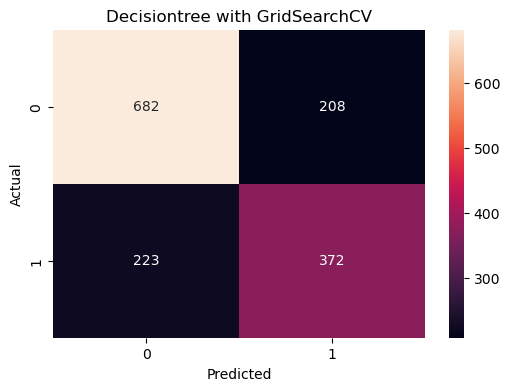

In [112]:
plt.figure(figsize=(6,4))
sns.heatmap(cm_dt_gs,annot=True,fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Decisiontree with GridSearchCV')
plt.show()

In [113]:
y_test_pred_6 = y_test_pred_dt_gs
y_prob_dt_gs = best_dt.predict_proba(x_test)[:,1]
recall_dt_gs = recall_score(y_test,y_test_pred_6)
f1_dt_gs = f1_score(y_test,y_test_pred_6)
roc_auc_dt_gs = roc_auc_score(y_test,y_prob_dt_gs)
print("DecisionTree (GS) Metrics:")
print("Recall:", recall_dt_gs)
print("F1:",f1_dt_gs)
print("ROC-AUC:",roc_auc_dt_gs)

DecisionTree (GS) Metrics:
Recall: 0.6252100840336134
F1: 0.6331914893617021
ROC-AUC: 0.7787602681522048


**5. RANDOMFOREST CLASSIFIER:**

In [114]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)
rf.fit(x_train_sm,y_train_sm)

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [115]:
y_train_pred_rf = rf.predict(x_train_sm)
y_test_pred_rf = rf.predict(x_test)
y_test_pred_rf

array([0, 0, 1, ..., 0, 0, 0], shape=(1485,))

In [116]:
accuracy_train_rf = accuracy_score(y_train_sm,y_train_pred_rf)
print("Accuracy_train_rf:",accuracy_train_rf)

accuracy_test_rf = accuracy_score(y_test,y_test_pred_rf)
print("Accuracy_test_rf:",accuracy_test_rf)

Accuracy_train_rf: 0.8522632602054985
Accuracy_test_rf: 0.696969696969697


In [117]:
classification_report_train_rf = classification_report(y_train_sm,y_train_pred_rf)
print("Classification Report_train_rf:\n",classification_report_train_rf)

classification_report_test_rf = classification_report(y_test,y_test_pred_rf)
print("\nClassification Report_test_rf:\n", classification_report_test_rf)

Classification Report_train_rf:
               precision    recall  f1-score   support

           0       0.86      0.84      0.85      3601
           1       0.85      0.86      0.85      3601

    accuracy                           0.85      7202
   macro avg       0.85      0.85      0.85      7202
weighted avg       0.85      0.85      0.85      7202


Classification Report_test_rf:
               precision    recall  f1-score   support

           0       0.74      0.76      0.75       890
           1       0.63      0.60      0.61       595

    accuracy                           0.70      1485
   macro avg       0.68      0.68      0.68      1485
weighted avg       0.70      0.70      0.70      1485



In [118]:
cm_rf = confusion_matrix(y_test,y_test_pred_rf)
print("Confusion Matrix Test Set:\n", cm_rf)

Confusion Matrix Test Set:
 [[677 213]
 [237 358]]


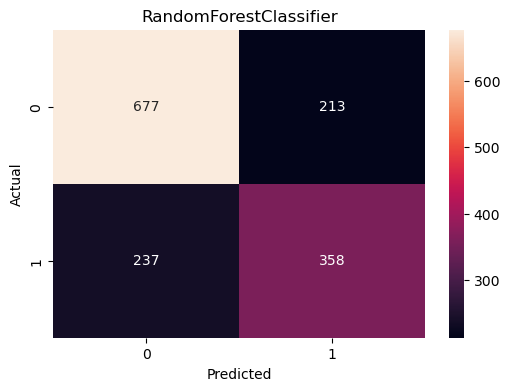

In [119]:
plt.figure(figsize=(6,4))
sns.heatmap(cm_rf,annot=True,fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('RandomForestClassifier')
plt.show()

In [120]:
y_test_pred_7 = y_test_pred_rf
y_prob_rf = rf.predict_proba(x_test)[:,1]
recall_rf = recall_score(y_test,y_test_pred_7)
f1_rf = f1_score(y_test,y_test_pred_7)
roc_auc_rf = roc_auc_score(y_test,y_prob_rf)
print("Random Forest Metrics:")
print("Recall:",recall_rf)
print("F1-score:",f1_rf)
print("ROC-AUC:",roc_auc_rf)

Random Forest Metrics:
Recall: 0.6016806722689075
F1-score: 0.614065180102916
ROC-AUC: 0.7591115097724483


**Hyperparameter Tuning - RandomForest Classifier:**

In [121]:
from sklearn.model_selection import GridSearchCV

param_grid_rf = {
    'n_estimators' : [100,200,300],
    'max_depth' : [5,10,None],
    'min_samples_split' : [2,5],
    'min_samples_leaf' : [1,3]
}
rf_gs = RandomForestClassifier(random_state=42)

In [122]:
grid_rf = GridSearchCV(
    estimator=rf_gs,
    param_grid=param_grid_rf,
    cv=5,
    scoring='f1',
    n_jobs=-1
)
grid_rf.fit(x_train_sm,y_train_sm)

,estimator,RandomForestC...ndom_state=42)
,param_grid,"{'max_depth': [5, 10, ...], 'min_samples_leaf': [1, 3], 'min_samples_split': [2, 5], 'n_estimators': [100, 200, ...]}"
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,200


In [123]:
print("Best parametrs:",grid_rf.best_params_)
best_rf = grid_rf.best_estimator_

Best parametrs: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}


In [124]:
y_train_pred_rf_gs = best_rf.predict(x_train_sm)
y_test_pred_rf_gs = best_rf.predict(x_test)
y_test_pred_rf_gs

array([0, 0, 1, ..., 0, 0, 0], shape=(1485,))

In [125]:
accuracy_train_rf_gs = accuracy_score(y_train_sm,y_train_pred_rf_gs)
print("Accuracy_train_rf_gs:",accuracy_train_rf_gs)

accuracy_test_rf_gs  = accuracy_score(y_test,y_test_pred_rf_gs)
print("Accuracy_test_rf_gs:",accuracy_test_rf_gs)



Accuracy_train_rf_gs: 0.7961677311857818
Accuracy_test_rf_gs: 0.7272727272727273


In [126]:
classification_report_train_rf_gs = classification_report(y_train_sm,y_train_pred_rf_gs)
print("Classification Report_train_rf_gs:\n",classification_report_train_rf_gs)

classification_report_test_rf_gs = classification_report(y_test,y_test_pred_rf_gs)
print("\nClassification Report_test_rf_gs:\n",classification_report_test_rf_gs)

Classification Report_train_rf_gs:
               precision    recall  f1-score   support

           0       0.81      0.77      0.79      3601
           1       0.78      0.82      0.80      3601

    accuracy                           0.80      7202
   macro avg       0.80      0.80      0.80      7202
weighted avg       0.80      0.80      0.80      7202


Classification Report_test_rf_gs:
               precision    recall  f1-score   support

           0       0.78      0.77      0.77       890
           1       0.66      0.67      0.66       595

    accuracy                           0.73      1485
   macro avg       0.72      0.72      0.72      1485
weighted avg       0.73      0.73      0.73      1485



In [127]:
cm_rf_gs = confusion_matrix(y_test,y_test_pred_rf_gs)
print("Confusion Matrix Test Set:\n",cm_rf_gs)

Confusion Matrix Test Set:
 [[681 209]
 [196 399]]


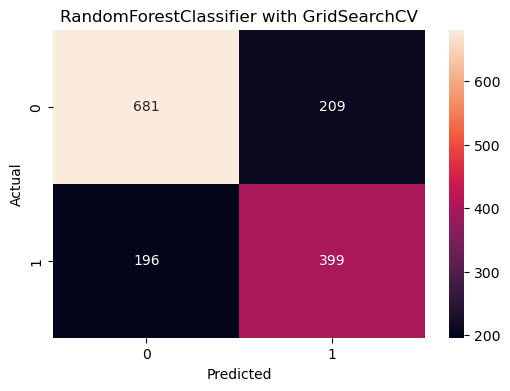

In [128]:
plt.figure(figsize=(6,4))
sns.heatmap(cm_rf_gs,annot=True,fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('RandomForestClassifier with GridSearchCV')
plt.show()

In [129]:
y_test_pred_8 = y_test_pred_rf_gs
y_prob_rf_gs = best_rf.predict_proba(x_test)[:,1]
recall_rf_gs = recall_score(y_test,y_test_pred_8)
f1_rf_gs = f1_score(y_test,y_test_pred_8)
roc_auc_rf_gs = roc_auc_score(y_test,y_prob_rf_gs)
print("Random Forest (GS) Metrics:")
print("Recall:",recall_rf_gs)
print("F1-score:",f1_rf_gs)
print("ROC-AUC:",roc_auc_rf_gs)

Random Forest (GS) Metrics:
Recall: 0.6705882352941176
F1-score: 0.6633416458852868
ROC-AUC: 0.7989226701916722


**6. XGBOOOST CLASSIFIER:**

In [130]:
from xgboost import XGBClassifier
xgb = XGBClassifier(
    n_estimators = 200,
    learning_rate = 0.1,
    max_depth = 5,
    random_satate = 42,
    use_label_encoder = False,
    eval_metric = 'logloss'
)
xgb.fit(x_train_sm,y_train_sm)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [131]:
y_train_pred_xgb = xgb.predict(x_train_sm)
y_test_pred_xgb = xgb.predict(x_test)
y_test_pred_xgb

array([0, 0, 1, ..., 0, 0, 0], shape=(1485,))

In [132]:
accuracy_train_xgb = accuracy_score(y_train_sm,y_train_pred_xgb)
print("Accuracy_train_xgb:",accuracy_train_xgb)

accuracy_test_xgb = accuracy_score(y_test,y_test_pred_xgb)
print("Accuracy_test_xgb:",accuracy_test_xgb)

Accuracy_train_xgb: 0.7858928075534574
Accuracy_test_xgb: 0.7265993265993266


In [133]:
classification_report_train_xgb = classification_report(y_train_sm,y_train_pred_xgb)
print("Classification Report_train_xgb:\n",classification_report_train_xgb)

classification_report_test_xgb = classification_report(y_test,y_test_pred_xgb)
print("\nClassification Report_test_xgb:\n",classification_report_test_xgb)

Classification Report_train_xgb:
               precision    recall  f1-score   support

           0       0.78      0.79      0.79      3601
           1       0.79      0.78      0.78      3601

    accuracy                           0.79      7202
   macro avg       0.79      0.79      0.79      7202
weighted avg       0.79      0.79      0.79      7202


Classification Report_test_xgb:
               precision    recall  f1-score   support

           0       0.77      0.78      0.77       890
           1       0.66      0.65      0.65       595

    accuracy                           0.73      1485
   macro avg       0.72      0.71      0.71      1485
weighted avg       0.73      0.73      0.73      1485



In [134]:
cm_xgb = confusion_matrix(y_test,y_test_pred_xgb)
print("Confusion Matrix Test Set:\n",cm_xgb)

Confusion Matrix Test Set:
 [[694 196]
 [210 385]]


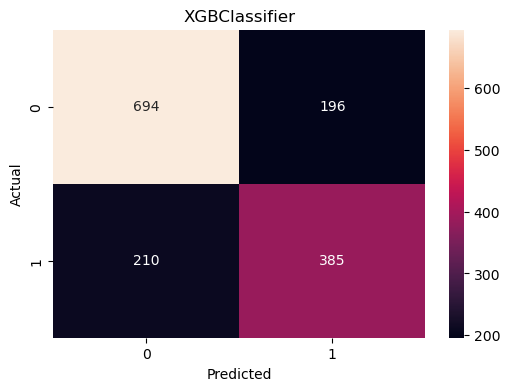

In [135]:
plt.figure(figsize=(6,4))
sns.heatmap(cm_xgb,annot=True,fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('XGBClassifier')
plt.show()

In [136]:
y_test_pred_9 = y_test_pred_xgb
y_prob_xgb = xgb.predict_proba(x_test)[:,1]
recall_xgb = recall_score(y_test,y_test_pred_9)
f1_xgb = f1_score(y_test,y_test_pred_9)
roc_auc_xgb = roc_auc_score(y_test,y_prob_xgb)
print("XGBoost Metrics:")
print("Recall:",recall_xgb)
print("F1-score:",f1_xgb)
print("ROC-AUC:",roc_auc_xgb)

XGBoost Metrics:
Recall: 0.6470588235294118
F1-score: 0.6547619047619048
ROC-AUC: 0.8079029364554812


**Hyperparameter Tuning - XGBoost Classifier:**

In [137]:
param_grid_xgb = {
    'n_estimators' : [200,300],
    'max_depth' : [3,5,7],
    'learning_rate' : [0.01,0.1],
    'subsample' : [0.8,1]
}

In [138]:
xgb_gs = XGBClassifier(
    random_state = 42,
    use_label_encoder = False,
    eval_metric = 'logloss'
)

In [139]:
grid_xgb = GridSearchCV(
    estimator=xgb_gs,
    param_grid=param_grid_xgb,
    scoring='f1',
    cv=5,
    n_jobs=-1,
)
grid_xgb.fit(x_train_sm,y_train_sm)

,estimator,"XGBClassifier...ree=None, ...)"
,param_grid,"{'learning_rate': [0.01, 0.1], 'max_depth': [3, 5, ...], 'n_estimators': [200, 300], 'subsample': [0.8, 1]}"
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,objective,'binary:logistic'


In [140]:
best_xgb  = grid_xgb.best_estimator_
print("Best Parameters:\n",grid_xgb.best_params_)

Best Parameters:
 {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 300, 'subsample': 1}


In [141]:
y_train_pred_xgb_gs = best_xgb.predict(x_train_sm)
y_test_pred_xgb_gs = best_xgb.predict(x_test)
y_test_pred_xgb_gs

array([0, 0, 1, ..., 0, 0, 0], shape=(1485,))

In [142]:
accuracy_train_xgb_gs = accuracy_score(y_train_sm,y_train_pred_xgb_gs)
print("Accuracy_train_xgb:",accuracy_train_xgb_gs)

accuracy_test_xgb_gs  = accuracy_score(y_test,y_test_pred_xgb_gs)
print("Accuracy_test_xgb_gs:",accuracy_test_xgb_gs)

Accuracy_train_xgb: 0.7958900305470703
Accuracy_test_xgb_gs: 0.7218855218855219


In [143]:
classification_report_train_xgb_gs = classification_report(y_train_sm,y_train_pred_xgb_gs)
print("Classification Report_train_xgb_gs:\n", classification_report_train_xgb_gs)

classification_report_test_xgb_gs = classification_report(y_test,y_test_pred_xgb_gs)
print("\nClassification Report_test_xgb_gs:\n",classification_report_test_xgb_gs)

Classification Report_train_xgb_gs:
               precision    recall  f1-score   support

           0       0.79      0.80      0.80      3601
           1       0.80      0.79      0.80      3601

    accuracy                           0.80      7202
   macro avg       0.80      0.80      0.80      7202
weighted avg       0.80      0.80      0.80      7202


Classification Report_test_xgb_gs:
               precision    recall  f1-score   support

           0       0.76      0.78      0.77       890
           1       0.66      0.64      0.65       595

    accuracy                           0.72      1485
   macro avg       0.71      0.71      0.71      1485
weighted avg       0.72      0.72      0.72      1485



In [144]:
cm_xgb_gs = confusion_matrix(y_test,y_test_pred_xgb_gs)
print("Confusion Matrix Test Set:\n", cm_xgb_gs)

Confusion Matrix Test Set:
 [[693 197]
 [216 379]]


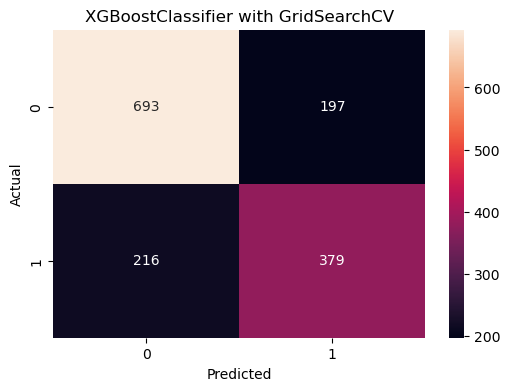

In [145]:
plt.figure(figsize=(6,4))
sns.heatmap(cm_xgb_gs,annot=True,fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('XGBoostClassifier with GridSearchCV')
plt.show()

In [146]:
y_test_pred_10 = y_test_pred_xgb_gs
y_prob_xgb_gs = best_xgb.predict_proba(x_test)[:,1]
recall_xgb_gs = recall_score(y_test,y_test_pred_10)
f1_xgb_gs = f1_score(y_test,y_test_pred_10)
roc_auc_xgb_gs = roc_auc_score(y_test,y_prob_xgb_gs)
print("XGBoost (GS) Metrics:")
print("Recall:",recall_xgb_gs)
print("F1-score:",f1_xgb_gs)
print("ROC-AUC:",roc_auc_xgb_gs)

XGBoost (GS) Metrics:
Recall: 0.6369747899159663
F1-score: 0.6473099914602903
ROC-AUC: 0.8051713719195543


In [147]:
from catboost import CatBoostClassifier
cat = CatBoostClassifier(
    iterations=200,
    depth=5,
    learning_rate=0.05,
    eval_metric = 'AUC',
    random_state = 42,
    verbose=0
)
cat.fit(x_train_sm,y_train_sm)

CatBoostClassifier(depth=5, eval_metric='AUC', iterations=200, learning_rate=0.05, random_state=42, verbose=0)

In [148]:
y_train_pred_cat = cat.predict(x_train_sm)
y_test_pred_cat = cat.predict(x_test)
y_test_pred_cat

array([0, 0, 1, ..., 0, 1, 0], shape=(1485,))

In [149]:
accuracy_train_cat = accuracy_score(y_train_sm,y_train_pred_cat)
print("Accuracy_train_cat:",accuracy_train_cat)

accuracy_test_cat = accuracy_score(y_test,y_test_pred_cat)
print("Accuracy_test_cat:",accuracy_test_cat)

Accuracy_train_cat: 0.755762288253263
Accuracy_test_cat: 0.7299663299663299


In [150]:
classification_report_train_cat = classification_report(y_train_sm,y_train_pred_cat)
print("Classification Report_train_cat:\n",classification_report_train_cat)

classification_report_test_cat = classification_report(y_test,y_test_pred_cat)
print("\nClassification Report_test_cat:\n",classification_report_test_cat)

Classification Report_train_cat:
               precision    recall  f1-score   support

           0       0.76      0.75      0.75      3601
           1       0.75      0.76      0.76      3601

    accuracy                           0.76      7202
   macro avg       0.76      0.76      0.76      7202
weighted avg       0.76      0.76      0.76      7202


Classification Report_test_cat:
               precision    recall  f1-score   support

           0       0.77      0.78      0.77       890
           1       0.66      0.66      0.66       595

    accuracy                           0.73      1485
   macro avg       0.72      0.72      0.72      1485
weighted avg       0.73      0.73      0.73      1485



In [151]:
cm_cat = confusion_matrix(y_test,y_test_pred_cat)
print("Confusion Matrix Test Set:\n", cm_cat)

Confusion Matrix Test Set:
 [[690 200]
 [201 394]]


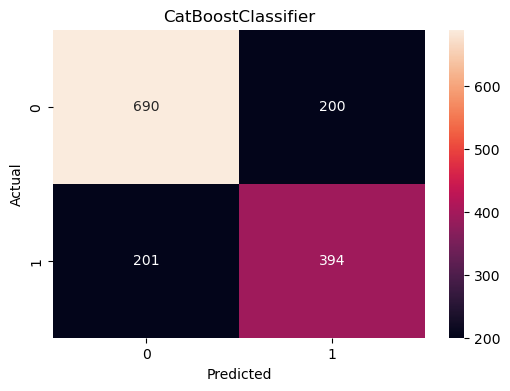

In [152]:
plt.figure(figsize=(6,4))
sns.heatmap(cm_cat,annot=True,fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('CatBoostClassifier')
plt.show()

In [153]:
y_test_pred_11 = y_test_pred_cat
y_prob_cat = cat.predict_proba(x_test)[:,1]
recall_cat = recall_score(y_test,y_test_pred_11)
f1_cat = f1_score(y_test,y_test_pred_11)
roc_auc_cat = roc_auc_score(y_test,y_prob_cat)
print("CatBoost Metrics:")
print("Recall:",recall_cat)
print("F1-score:",f1_cat)
print("ROC-AUC:",roc_auc_cat)

CatBoost Metrics:
Recall: 0.6621848739495798
F1-score: 0.6627417998317914
ROC-AUC: 0.8079416485695402


**Hyperparameter Tuning - CatBoost Classifier:**

In [154]:
param_grid_cat = {
    'iterations' : [200,300],
    'depth' : [4,5,6],
    'learning_rate' : [0.03,0.05,0.1],
    'l2_leaf_reg' : [1,3,5]
}

In [155]:
cat_gs = CatBoostClassifier(
    eval_metric = 'AUC',
    random_state = 42,
    verbose = 0
)

In [156]:
grid_cat = GridSearchCV(
    estimator = cat_gs,
    param_grid=param_grid_cat,
    cv=5,
    scoring='f1',
    n_jobs = -1
)
grid_cat.fit(x_train_sm,y_train_sm)

,estimator,"CatBoostClass...42, verbose=0)"
,param_grid,"{'depth': [4, 5, ...], 'iterations': [200, 300], 'l2_leaf_reg': [1, 3, ...], 'learning_rate': [0.03, 0.05, ...]}"
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False


In [157]:
best_cat = grid_cat.best_estimator_
print("Best Parameters:",grid_cat.best_params_)

Best Parameters: {'depth': 5, 'iterations': 300, 'l2_leaf_reg': 5, 'learning_rate': 0.05}


In [158]:
y_train_pred_cat_gs = best_cat.predict(x_train_sm)
y_test_pred_cat_gs = best_cat.predict(x_test)
y_test_pred_cat

array([0, 0, 1, ..., 0, 1, 0], shape=(1485,))

In [159]:
accuracy_train_cat_gs = accuracy_score(y_train_sm,y_train_pred_cat_gs)
print("Accuracy_train_cat_gs:",accuracy_train_cat_gs)

accuracy_test_cat_gs = accuracy_score(y_test,y_test_pred_cat_gs)
print("Accuracy_test_cat_gs:",accuracy_test_cat_gs)


Accuracy_train_cat_gs: 0.7654818106081644
Accuracy_test_cat_gs: 0.7346801346801347


In [160]:
classification_report_train_cat_gs = classification_report(y_train_sm,y_train_pred_cat_gs)
print("Calssification Report_train_cat_gs:\n", classification_report_train_cat_gs)

classification_report_test_cat_gs  = classification_report(y_test,y_test_pred_cat_gs)
print("\nClassification Report_test_cat_gs:\n",classification_report_test_cat_gs)

Calssification Report_train_cat_gs:
               precision    recall  f1-score   support

           0       0.77      0.76      0.76      3601
           1       0.76      0.77      0.77      3601

    accuracy                           0.77      7202
   macro avg       0.77      0.77      0.77      7202
weighted avg       0.77      0.77      0.77      7202


Classification Report_test_cat_gs:
               precision    recall  f1-score   support

           0       0.78      0.78      0.78       890
           1       0.67      0.67      0.67       595

    accuracy                           0.73      1485
   macro avg       0.72      0.72      0.72      1485
weighted avg       0.73      0.73      0.73      1485



In [161]:
cm_cat_gs = confusion_matrix(y_test,y_test_pred_cat_gs)
print("Confusion Matrix Test Set:\n",cm_cat_gs)

Confusion Matrix Test Set:
 [[692 198]
 [196 399]]


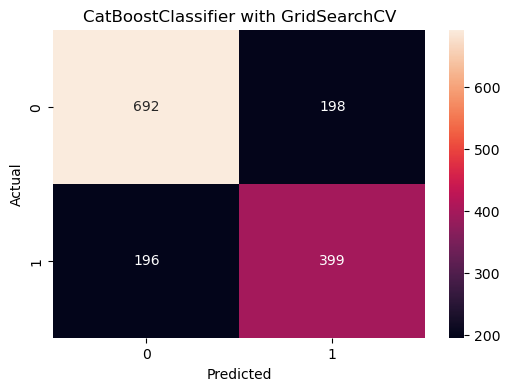

In [162]:
plt.figure(figsize=(6,4))
sns.heatmap(cm_cat_gs,annot=True,fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('CatBoostClassifier with GridSearchCV')
plt.show()

In [163]:
y_test_pred_12 = y_test_pred_cat_gs
y_prob_cat_gs = best_cat.predict_proba(x_test)[:,1]
recall_cat_gs = recall_score(y_test,y_test_pred_12)
f1_cat_gs = f1_score(y_test,y_test_pred_12)
roc_auc_cat_gs = roc_auc_score(y_test,y_prob_cat_gs)
print("CatBoost (GS) Metrics:")
print("Recall:",recall_cat_gs)
print("F1-score:",f1_cat_gs)
print("ROC-AUC:",roc_auc_cat_gs)

CatBoost (GS) Metrics:
Recall: 0.6705882352941176
F1-score: 0.6694630872483222
ROC-AUC: 0.8120753469927297


**MODEL EVALUATION & COMPARISON:**

In [164]:
model_comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "KNN classifier", "KNN (GS)", "GreadientBossting","Decisiontree","Decisiontree (GS)","randomforest", "Randomforest (GS)", "XGBoost", "XGBoost (GS)","CatBoost","CatBoost (GS)"],
    "Recall": [recall_lgr, recall_knn,recall_knn_gs,recall_gb,recall_dt, recall_dt_gs,recall_rf, recall_rf_gs, recall_xgb, recall_xgb_gs, recall_cat,recall_cat_gs],
    "F1_Score": [f1_lgr, f1_knn,f1_knn_gs, f1_gb,f1_dt,f1_dt_gs,f1_rf, f1_rf_gs, f1_xgb,f1_xgb_gs, f1_cat,f1_cat_gs],
    "ROC_AUC": [roc_auc_lgr, roc_auc_knn, roc_auc_knn_gs,roc_auc_gb,roc_auc_dt,roc_auc_dt_gs, roc_auc_rf,roc_auc_rf_gs, roc_auc_xgb,roc_auc_xgb_gs, roc_auc_cat,roc_auc_cat_gs]
})

model_comparison.index = model_comparison.index+1
model_comparison


,Model,Recall,F1_Score,ROC_AUC
1,Logistic Regression,0.504202,0.490597,0.608484
2,KNN classifier,0.593277,0.602389,0.745051
3,KNN (GS),0.636975,0.623355,0.765043
4,GreadientBossting,0.675630,0.661728,0.810325
5,Decisiontree,0.541176,0.575000,0.704657
6,Decisiontree (GS),0.625210,0.633191,0.778760
7,randomforest,0.601681,0.614065,0.759112
8,Randomforest (GS),0.670588,0.663342,0.798923
9,XGBoost,0.647059,0.654762,0.807903
10,XGBoost (GS),0.636975,0.647310,0.805171


**Observation:**

- Logistic Regression shows the lowest performance, indicating that the dataset does not follow a strong linear relationship.
- Hyperparameter tuning significantly improved models like KNN, Decision Tree, Random Forest, and CatBoost.
- Ensemble methods (Random Forest, Gradient Boosting, XGBoost, CatBoost) outperform traditional models in terms of Recall, F1-score, and ROC-AUC.
- Boosting algorithms (Gradient Boosting, XGBoost, CatBoost) achieve higher ROC-AUC (>0.80), showing better ability to distinguish between classes.
- CatBoost (GridSearch tuned) delivers the best overall performance with the highest ROC-AUC (0.812) and F1-score (0.669), making it the most suitable final model.

In [165]:
Model_Comparison = pd.DataFrame({
    'Model': [
        'Logistic Regresson',
        'KNN Classifier',
        'KNN (GS)',
        'GradientBoosting Classifier',
        'Decision Tree Classifier',
        'Decision Tree (GS)',
        'Random Forest Classifier',
        'Random Forest (GS)',
        'XGB Classifier',
        'XGB Classifier (GS)',
        'CatBoost Classifier',
        'CatBoost (GS)'
        
    ],
    'Train Score': [
        accuracy_train_lgr,
        accuracy_train_knn,
        accuracy_train_knn_gs,
        accuracy_train_gb,
        accuracy_train_dt,
        accuracy_train_dt_gs,
        accuracy_train_rf,
        accuracy_train_rf_gs,
        accuracy_train_xgb,
        accuracy_train_xgb_gs,
        accuracy_train_cat,
        accuracy_train_cat_gs   
        
    ],

    'Test Score': [
        accuracy_test_lgr,
        accuracy_test_knn,
        accuracy_test_knn_gs,
        accuracy_test_gb,
        accuracy_test_dt,
        accuracy_test_dt_gs,
        accuracy_test_rf,
        accuracy_test_rf_gs,
        accuracy_test_xgb,
        accuracy_test_xgb_gs,
        accuracy_test_cat,
        accuracy_test_cat_gs
        
        
    ]
})

Model_Comparison.index = Model_Comparison.index+1
Model_Comparison


,Model,Train Score,Test Score
1,Logistic Regresson,0.574424,0.580471
2,KNN Classifier,0.774646,0.686195
3,KNN (GS),0.774646,0.691582
4,GradientBoosting Classifier,0.761455,0.723232
5,Decision Tree Classifier,0.852263,0.679461
6,Decision Tree (GS),0.751597,0.709764
7,Random Forest Classifier,0.852263,0.696970
8,Random Forest (GS),0.796168,0.727273
9,XGB Classifier,0.785893,0.726599
10,XGB Classifier (GS),0.795890,0.721886


**Observation:**

- Decision Tree and Random Forest show very high train accuracy (~0.85) but much lower test accuracy (~0.68–0.69), indicating overfitting.
- Logistic Regression shows nearly equal train and test scores (~0.57–0.58), suggesting stable performance but low predictive power.
- KNN shows a noticeable gap between train and test accuracy, indicating moderate overfitting.
- Boosting models (Gradient Boosting, XGBoost, CatBoost) display balanced train and test scores, indicating better generalization capability.
- CatBoost achieves the highest test accuracy (73.46%) with a small train–test gap, making it the most stable and best-performing model among all.

In [166]:
Model_Comparison['Generalization Gap'] = (
    Model_Comparison['Train Score'] - Model_Comparison['Test Score']
)

Model_Comparison


,Model,Train Score,Test Score,Generalization Gap
1,Logistic Regresson,0.574424,0.580471,-0.006048
2,KNN Classifier,0.774646,0.686195,0.088451
3,KNN (GS),0.774646,0.691582,0.083063
4,GradientBoosting Classifier,0.761455,0.723232,0.038223
5,Decision Tree Classifier,0.852263,0.679461,0.172802
6,Decision Tree (GS),0.751597,0.709764,0.041832
7,Random Forest Classifier,0.852263,0.696970,0.155294
8,Random Forest (GS),0.796168,0.727273,0.068895
9,XGB Classifier,0.785893,0.726599,0.059293
10,XGB Classifier (GS),0.795890,0.721886,0.074005


**Generalization Gap Analysis:**

- Decision Tree (0.17) and Random Forest (0.15) show the highest generalization gaps, indicating strong overfitting and poor stability on unseen data.
- KNN models (~0.08) show moderate overfitting, as the train accuracy is noticeably higher than test accuracy.
- Gradient Boosting (0.038) and Decision Tree (0.041) show significantly lower gaps, indicating better generalization compared to basic tree models.
- CatBoost models (0.025–0.030) have the lowest generalization gap among all models, showing strong stability and consistent performance.
- Overall, boosting-based models demonstrate better generalization ability, making them more reliable for real-world lead prediction tasks.

**Final Model Selection**

Among all the evaluated models, the *CatBoost Classifier* was selected as the final model.

**Reasons for Selection:**

- Achieved the highest F1-score, indicating the best balance between precision and recall.
- Obtained the highest ROC-AUC score (0.812), demonstrating strong class-separation capability.
- Delivered high recall, ensuring effective identification of potential high-value leads, which is critical for business impact.
- Showed the lowest generalization gap, indicating stable and reliable performance on unseen data.
- Outperformed other models, including Logistic Regression, KNN, Decision Tree, Random Forest, and XGBoost, in overall balanced metrics.

**ROC & Precision–Recall Curve Analysis (CatBoost Classifier):**

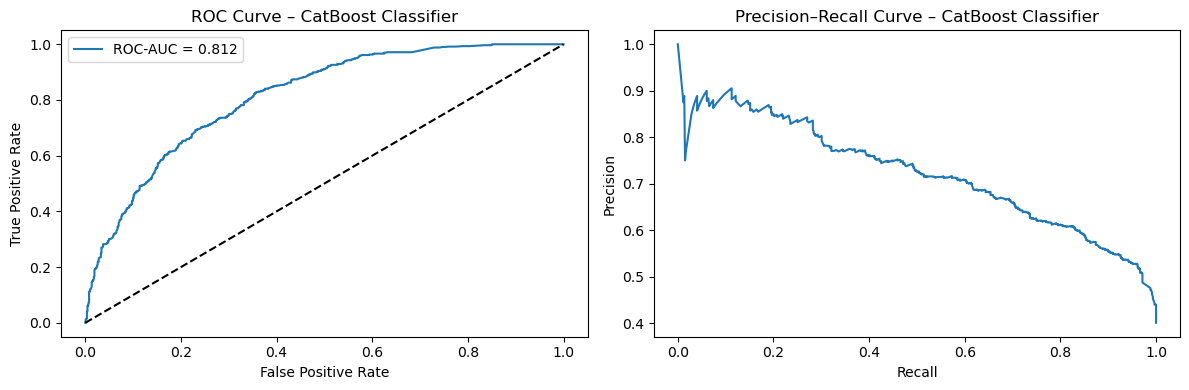

In [167]:
from sklearn.metrics import roc_curve, precision_recall_curve

fpr, tpr, _ = roc_curve(y_test, y_prob_cat_gs)
roc_auc = roc_auc_score(y_test, y_prob_cat_gs)

precision, recall, _ = precision_recall_curve(y_test, y_prob_cat_gs)
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(fpr, tpr, label=f'ROC-AUC = {roc_auc:.3f}')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve – CatBoost Classifier')
plt.legend()

plt.subplot(1,2,2)
plt.plot(recall, precision)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision–Recall Curve – CatBoost Classifier')

plt.tight_layout()
plt.show()


**Observation:**

- The ROC-AUC score of 0.812 indicates strong class discrimination ability, showing the model effectively separates positive and negative classes.
- The ROC curve stays well above the diagonal baseline, confirming that the model performs significantly better than random classification.
- The Precision–Recall curve shows high precision at lower recall levels and a gradual decline as recall increases, indicating a balanced trade-off between identifying positives and maintaining prediction accuracy.
- Overall, the curves demonstrate that CatBoost provides stable and reliable performance, especially in handling classification performance across different threshold levels.

         Feature  Importance
1         source   26.965727
2    sales_agent   25.987966
0     product_id   23.217916
3       location   18.784617
4  delivery_mode    5.043775


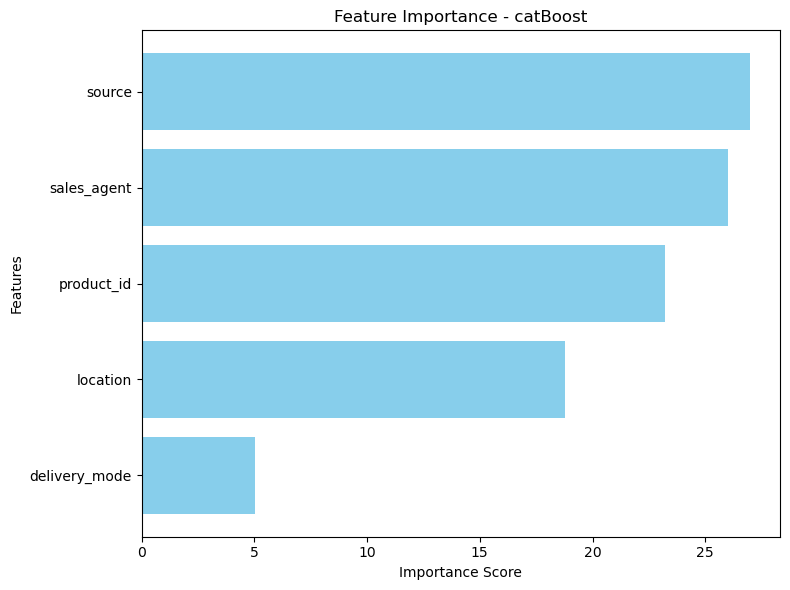

In [168]:
best_cat = grid_cat.best_estimator_
importance = best_cat.get_feature_importance()
feature_imp = pd.DataFrame({
    'Feature' : x.columns,
    'Importance' : importance
}).sort_values(by='Importance',ascending=False)
print(feature_imp)

plt.figure(figsize=(8,6))
plt.barh(feature_imp['Feature'],feature_imp['Importance'],color='skyblue')
plt.gca().invert_yaxis()
plt.title("Feature Importance - catBoost")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.tight_layout()
plt.show()

**Feature Importance Insights:**

- Source is the most influential feature (~27%), indicating that the origin of the lead plays a critical role in determining conversion probability.
- Sales Agent and Product ID also have strong impact, suggesting that both salesperson effectiveness and product type significantly influence lead outcomes.
- Delivery Mode has the lowest importance (~5%), indicating it contributes minimally to prediction compared to other business-related features.

**CHALLENGES:**

Imbalanced Target Distribution:

- The lead conversion dataset contained fewer converted leads compared to non-converted leads.
- This imbalance made overall accuracy unreliable as a standalone performance metric.
- Advanced evaluation metrics such as Recall, F1-score, and ROC-AUC were prioritized to ensure proper minority class detection.

Model Performance Variability:

- Different algorithms showed varying strengths; some achieved high training accuracy but failed to generalize well on test data.
- Tree-based models showed signs of overfitting, requiring careful evaluation of generalization gaps.
- Multiple models were compared systematically before identifying the most stable and high-performing solution.

Feature Encoding Complexity:

- Several categorical features (e.g., source, sales_agent, location) required appropriate encoding techniques.
- Selecting suitable encoding methods was crucial to prevent information loss and maintain predictive power.
- Improper encoding could have negatively impacted model performance.

Evaluation Metric Selection:

- Since business impact depends on correctly identifying potential converting leads, Recall and F1-score were emphasized over raw accuracy.
- Balancing class-separation ability (ROC-AUC) with real-world applicability required deeper metric analysis.

Overfitting Control & Stability:

- Some models showed a noticeable gap between training and testing performance.
- Ensuring stable generalization required careful comparison of train-test scores and selection of a robust final model.

**Limitations of SMOTE & Alternative Approaches:**

**Limitations of SMOTE:**

- Synthetic Data Generation - SMOTE creates artificial minority samples, which may not perfectly represent real-world lead behavior.
- Risk of Overfitting - The model may learn synthetic patterns instead of genuine data patterns, affecting generalization.
- Noise Amplification - If the minority class contains noisy data, SMOTE can amplify that noise.
- Limited Handling of Complex Feature Relationships - SMOTE does not fully consider complex interactions between features while generating new samples.
- Challenges with Categorical Features - Basic SMOTE works best with numerical features and may not perform well with categorical variables unless modified versions are used.

**Alternative Approaches:**

- Class Weight Adjustment- Assign higher penalty to minority class misclassification (supported in Logistic Regression, Random Forest, CatBoost, etc.).
- Undersampling the Majority Class - Reduce majority class samples to create balance, though this may reduce available information.
- Ensemble Methods- Use models like Balanced Random Forest, XGBoost, or CatBoost with class weights for better handling of imbalance.
- Threshold Tuning - Adjust decision threshold instead of default 0.5 to improve recall for minority class.
- Hybrid Sampling Techniques - Use advanced methods like SMOTEENN or SMOTETomek that combine oversampling with noise removal.

**CONCLUSION:**

This project developed a machine learning model to predict lead conversion using historical sales data. After data preprocessing, feature encoding, and handling class imbalance, multiple models were evaluated using Recall, F1-score, and ROC-AUC.

The CatBoost Classifier was selected as the final model due to its strong class-separation ability, balanced performance, and stable generalization. The model can effectively support sales teams in identifying high-potential leads and improving conversion strategies